## imports & setup

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

path = Path(r"D:\be-mlsys-assignment-dataset\candidate_tiles")
VALID_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

## scan tiles into a DataFrame

In [2]:
records = []
files = [f for f in path.rglob("*") if f.suffix.lower() in VALID_EXTS]

for f in files:
    try:
        with Image.open(f) as img:
            width, height = img.size
            mode = img.mode
            arr = np.array(img)
            records.append({
                "filename": f.name,
                "width": width,
                "height": height,
                "dimensions": f"{width}x{height}",
                "mode": mode,
                "channels": arr.shape[2] if arr.ndim == 3 else 1,
                "dtype": str(arr.dtype),
                "min_val": arr.min(),
                "max_val": arr.max(),
                "mean_val": round(float(arr.mean()), 2),
            })
    except Exception as e:
        print(f"Failed: {f} -> {e}")

df = pd.DataFrame(records)
print(f"Loaded {len(df)} tiles")
df.head()

Loaded 1050 tiles


,filename,width,height,dimensions,mode,channels,dtype,min_val,max_val,mean_val
0,AnnualCrop_01.png,64,64,64x64,RGB,3,uint8,50,184,117.05
1,AnnualCrop_02.png,64,64,64x64,RGB,3,uint8,51,170,97.69
2,AnnualCrop_03.png,64,64,64x64,RGB,3,uint8,86,255,181.27
3,AnnualCrop_04.png,64,64,64x64,RGB,3,uint8,105,212,138.70
4,AnnualCrop_05.png,64,64,64x64,RGB,3,uint8,58,255,161.92


## dimension consistency

In [3]:
unique_dims = df["dimensions"].unique()
if len(unique_dims) == 1:
    print(f"All tiles are identical: {unique_dims[0]}")
else:
    print(f"{len(unique_dims)} distinct dimensions found:")
    display(df["dimensions"].value_counts())

All tiles are identical: 64x64


## mode breakdown (RGB / RGBA / grayscale)

In [4]:
df["mode"].value_counts()

mode
RGB    1050
Name: count, dtype: int64

## normalization / value range check

In [5]:
print("min:", df["min_val"].min(), " max:", df["max_val"].max())
print("dtypes seen:", df["dtype"].unique().tolist())

if df["max_val"].max() <= 1.0:
    print("-> Already normalized to [0, 1]")
elif df["max_val"].max() <= 255:
    print("-> Raw uint8 [0, 255], not normalized")
else:
    print("-> Unusual range — check dtype/scale manually")

min: 12  max: 255
dtypes seen: ['uint8']
-> Raw uint8 [0, 255], not normalized


## quick visual sanity check

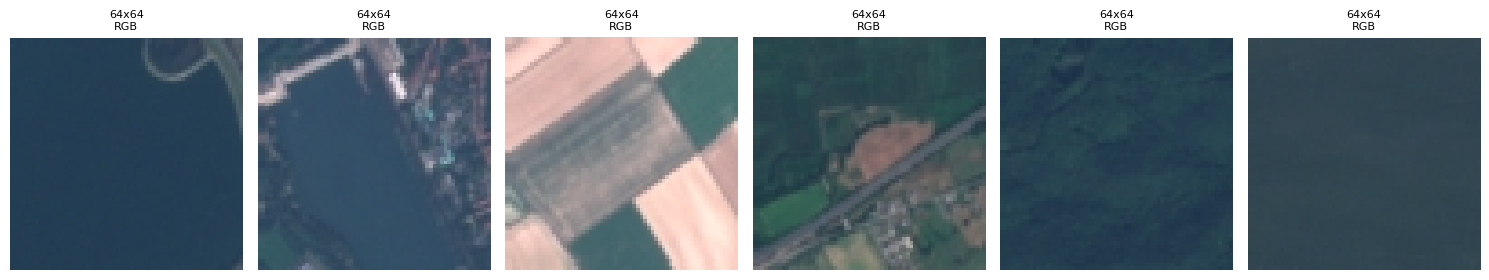

In [6]:
import matplotlib.pyplot as plt

sample = df.sample(min(6, len(df)))
fig, axes = plt.subplots(1, len(sample), figsize=(15, 3))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open([f for f in files if f.name == row["filename"]][0])
    ax.imshow(img)
    ax.set_title(f'{row["dimensions"]}\n{row["mode"]}', fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Input
PNG -> RGB 64×64 uint8 -> float32 -> [0,255] → [0,1] -> model-specific normalization -> classifier
*note: not nomalized

ResNet18 pretrained on ImageNet → replace final layer with 7-class head → fine-tune on candidate_tiles.

Why?
- 64×64 is tiny.
- CPU inference will be fast.
- ResNet18 is easy to understand and debug.
- Transfer learning gives us useful visual features without building a CNN from scratch.
- The seven classes are specific enough that a generic ImageNet classifier isn't sufficient by itself.
- The assignment explicitly says accuracy isn't the grading criterion.

## distribution

In [8]:
from pathlib import Path
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

path = Path(r"D:\be-mlsys-assignment-dataset\candidate_tiles")
VALID_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

records = []
for class_dir in sorted(p for p in path.iterdir() if p.is_dir()):
    for f in class_dir.iterdir():
        if f.suffix.lower() in VALID_EXTS:
            records.append({"filepath": str(f), "filename": f.name, "label": class_dir.name})

df = pd.DataFrame(records)
print(f"Loaded {len(df)} tiles across {df['label'].nunique()} classes")

Loaded 1050 tiles across 7 classes


### The table

In [9]:
counts = df["label"].value_counts().sort_index()

label_width = max(len(l) for l in counts.index) + 2
for label, count in counts.items():
    print(f"{label:<{label_width}}{count}")
print("-" * (label_width + 6))
print(f"{'Total':<{label_width}}{counts.sum()}")

AnnualCrop   150
Forest       150
Highway      150
Industrial   150
Residential  150
River        150
SeaLake      150
-------------------
Total        1050


In [10]:
train_df, val_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=42
)
print(f"Train: {len(train_df)}  |  Validation: {len(val_df)}")

split_check = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val": val_df["label"].value_counts(),
}).fillna(0).astype(int)
print(split_check)

Train: 840  |  Validation: 210
             train  val
label                  
AnnualCrop     120   30
Forest         120   30
Highway        120   30
Industrial     120   30
Residential    120   30
River          120   30
SeaLake        120   30


In [11]:
out_root = path.parent / "candidate_tiles_split"

for split_name, split_df in [("train", train_df), ("validation", val_df)]:
    for label in split_df["label"].unique():
        (out_root / split_name / label).mkdir(parents=True, exist_ok=True)
    for _, row in split_df.iterrows():
        shutil.copy2(Path(row["filepath"]), out_root / split_name / row["label"] / row["filename"])

print(f"Split written to: {out_root}")

Split written to: D:\be-mlsys-assignment-dataset\candidate_tiles_split


## have:

1,050 labelled candidate tiles
150 per class
840 train / 210 validation
Exactly 120 train + 30 validation per class
Therefore the split is perfectly balanced.
The separate eval_set remains untouched for final evaluation.

No CLASS imbalance

## exp set-up
```bash
candidate_tiles/
        │
        ├── 840 training tiles
        │      └── 120 × 7 classes
        │
        └── 210 validation tiles
               └── 30 × 7 classes

eval_set/
        │
        └── final evaluation only
                 ↓
          eval_labels.csv
```

## Model 

## set up

In [14]:
import time
import json
from pathlib import Path
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
 
data_root = Path(r"D:\be-mlsys-assignment-dataset\candidate_tiles_split")
eval_dir = Path(r"D:\be-mlsys-assignment-dataset\eval_set")
eval_labels_csv = Path(r"D:\be-mlsys-assignment-dataset\eval_labels.csv")
 
IMG_SIZE = 64          # bump to 224 if you want closer-to-ImageNet-scale inputs for ResNet/MobileNet
BATCH_SIZE = 32
EPOCHS = 10            # small on purpose - this is a comparison, not a leaderboard chase
SEED = 42
 
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cpu


## data loaders

In [15]:
# Normalize with ImageNet stats since ResNet18/MobileNetV3 are pretrained on it;
# SimpleCNN doesn't need this but reusing it keeps the comparison apples-to-apples.
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
 
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),   # satellite tiles have no "up" - safe augmentation here
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
 
train_ds = datasets.ImageFolder(data_root / "train", transform=train_tf)
val_ds = datasets.ImageFolder(data_root / "validation", transform=eval_tf)
 
class_names = train_ds.classes
print("Classes:", class_names)
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Classes: ['AnnualCrop', 'Forest', 'Highway', 'Industrial', 'Residential', 'River', 'SeaLake']
Train: 840  |  Val: 210


## model def

In [16]:
class SimpleCNN(nn.Module):
    """From-scratch baseline - establishes the floor to beat."""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        reduced = IMG_SIZE // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * reduced * reduced, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, x):
        return self.classifier(self.features(x))
 
 
def build_resnet18(num_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False          # freeze backbone
    m.fc = nn.Linear(m.fc.in_features, num_classes)   # only this head trains
    return m
 
 
def build_mobilenetv3(num_classes):
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    return m
 
 
MODEL_BUILDERS = {
    "SimpleCNN": lambda: SimpleCNN(len(class_names)),
    "ResNet18": lambda: build_resnet18(len(class_names)),
    "MobileNetV3": lambda: build_mobilenetv3(len(class_names)),
}

## train + eval helper func

In [17]:
def train_model(model, loader, epochs=EPOCHS, lr=1e-3):
    model.to(device)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=lr)
    criterion = nn.CrossEntropyLoss()
 
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        print(f"  epoch {epoch+1}/{epochs}  loss={running_loss/len(loader.dataset):.4f}")
    return model
 
 
@torch.no_grad()
def evaluate_model(model, loader, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
 
    # latency measured on single-image batches, CPU-equivalent path
    latencies = []
 
    for imgs, labels in loader:
        imgs = imgs.to(device)
        t0 = time.perf_counter()
        out = model(imgs)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        latencies.append((t1 - t0) / imgs.size(0))   # per-image latency for this batch
 
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
 
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision, recall, _, _ = precision_recall_fscore_support(
        all_labels, all_preds, labels=range(len(class_names)), zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
    avg_latency_ms = float(np.mean(latencies)) * 1000
 
    per_class = pd.DataFrame({
        "class": class_names,
        "precision": precision,
        "recall": recall,
    })
 
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "per_class": per_class,
        "confusion_matrix": cm,
        "avg_latency_ms_per_image": avg_latency_ms,
        "raw": {"preds": all_preds, "labels": all_labels, "probs": all_probs},
    }
 
 
def print_report(name, results):
    print(f"\n===== {name} =====")
    print(f"Accuracy:  {results['accuracy']:.4f}")
    print(f"Macro F1:  {results['macro_f1']:.4f}")
    print(f"Latency:   {results['avg_latency_ms_per_image']:.3f} ms/image")
    print("\nPer-class precision/recall:")
    print(results["per_class"].to_string(index=False))
    print("\nConfusion matrix (rows=true, cols=pred):")
    print(pd.DataFrame(results["confusion_matrix"], index=class_names, columns=class_names))

In [18]:
# compare all models
results_summary = {}
 
for name, builder in MODEL_BUILDERS.items():
    print(f"\nTraining {name}...")
    model = builder()
    model = train_model(model, train_loader)
    results = evaluate_model(model, val_loader, class_names)
    print_report(name, results)
    results_summary[name] = results
    torch.save(model.state_dict(), f"{name}_weights.pt")
 
# side-by-side comparison table
comparison = pd.DataFrame({
    name: {
        "accuracy": r["accuracy"],
        "macro_f1": r["macro_f1"],
        "latency_ms": r["avg_latency_ms_per_image"],
    }
    for name, r in results_summary.items()
}).T
print("\n===== Model comparison =====")
print(comparison)


Training SimpleCNN...
  epoch 1/10  loss=1.6039
  epoch 2/10  loss=1.1721
  epoch 3/10  loss=1.0512
  epoch 4/10  loss=0.8897
  epoch 5/10  loss=0.7986
  epoch 6/10  loss=0.7606
  epoch 7/10  loss=0.7083
  epoch 8/10  loss=0.5790
  epoch 9/10  loss=0.5729
  epoch 10/10  loss=0.5703

===== SimpleCNN =====
Accuracy:  0.7286
Macro F1:  0.7209
Latency:   1.306 ms/image

Per-class precision/recall:
      class  precision   recall
 AnnualCrop   0.954545 0.700000
     Forest   0.653846 0.566667
    Highway   0.764706 0.433333
 Industrial   0.805556 0.966667
Residential   0.756757 0.933333
      River   0.611111 0.733333
    SeaLake   0.638889 0.766667

Confusion matrix (rows=true, cols=pred):
             AnnualCrop  Forest  Highway  Industrial  Residential  River  \
AnnualCrop           21       0        1           0            1      7   
Forest                0      17        0           0            0      0   
Highway               1       1       13           4            6      5   


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\SHREYA/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:44<00:00, 1.06MB/s]


  epoch 1/10  loss=1.7823
  epoch 2/10  loss=1.0648
  epoch 3/10  loss=0.7985
  epoch 4/10  loss=0.6596
  epoch 5/10  loss=0.5837
  epoch 6/10  loss=0.5680
  epoch 7/10  loss=0.5111
  epoch 8/10  loss=0.4737
  epoch 9/10  loss=0.4452
  epoch 10/10  loss=0.4431

===== ResNet18 =====
Accuracy:  0.8810
Macro F1:  0.8813
Latency:   2.170 ms/image

Per-class precision/recall:
      class  precision   recall
 AnnualCrop   0.925926 0.833333
     Forest   0.965517 0.933333
    Highway   0.777778 0.700000
 Industrial   0.903226 0.933333
Residential   0.965517 0.933333
      River   0.722222 0.866667
    SeaLake   0.935484 0.966667

Confusion matrix (rows=true, cols=pred):
             AnnualCrop  Forest  Highway  Industrial  Residential  River  \
AnnualCrop           25       1        1           1            0      2   
Forest                0      28        1           0            0      0   
Highway               2       0       21           1            0      6   
Industrial            0 

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\SHREYA/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:17<00:00, 581kB/s]


  epoch 1/10  loss=1.6208
  epoch 2/10  loss=1.0217
  epoch 3/10  loss=0.9278
  epoch 4/10  loss=0.7475
  epoch 5/10  loss=0.7321
  epoch 6/10  loss=0.7005
  epoch 7/10  loss=0.6987
  epoch 8/10  loss=0.6016
  epoch 9/10  loss=0.6129
  epoch 10/10  loss=0.6337

===== MobileNetV3 =====
Accuracy:  0.8143
Macro F1:  0.8097
Latency:   1.779 ms/image

Per-class precision/recall:
      class  precision   recall
 AnnualCrop   0.851852 0.766667
     Forest   0.935484 0.966667
    Highway   0.666667 0.533333
 Industrial   0.806452 0.833333
Residential   0.875000 0.933333
      River   0.677419 0.700000
    SeaLake   0.852941 0.966667

Confusion matrix (rows=true, cols=pred):
             AnnualCrop  Forest  Highway  Industrial  Residential  River  \
AnnualCrop           23       1        0           1            0      2   
Forest                0      29        0           0            0      0   
Highway               1       1       16           4            3      5   
Industrial           

### confidence handling (predicted_class / confidence / status)

| Model        |   Accuracy |   Macro F1 | Latency/image |
| ------------ | ---------: | ---------: | ------------: |
| SimpleCNN    |     72.86% |     72.09% |       1.31 ms |
| MobileNetV3  |     81.43% |     80.97% |       1.78 ms |
| **ResNet18** | **88.10%** | **88.13%** |       2.17 ms |

note - ResNet18 costs only ~0.9 ms more than MobileNetV3 per image but gains ~6.7 percentage points of accuracy.
ResNet18 achieved the strongest validation accuracy and macro F1 (88.1% / 88.1%) at approximately 2.17 ms/image on the development machine. Given the offline CPU requirement and the relatively small latency difference versus MobileNetV3, I selected ResNet18 for the working slice.

In [19]:
def classify_with_status(probs, class_names, threshold=0.5):
    """
    Wraps a raw softmax vector into a decision-aware prediction.
    Does NOT claim calibrated probability - just reports max-softmax
    confidence and flags predictions below `threshold` as uncertain.
    """
    idx = int(np.argmax(probs))
    confidence = float(probs[idx])
    status = "confident" if confidence >= threshold else "uncertain"
    return {
        "predicted_class": class_names[idx],
        "confidence": round(confidence, 4),
        "status": status,
    }
 
 
def confidence_report(results, class_names, threshold=0.5):
    """Applies classify_with_status across a validation run and summarizes
    how many predictions would be flagged uncertain at this threshold,
    and how accuracy differs between confident vs uncertain predictions."""
    rows = []
    for probs, true_idx in zip(results["raw"]["probs"], results["raw"]["labels"]):
        decision = classify_with_status(probs, class_names, threshold)
        decision["true_class"] = class_names[true_idx]
        decision["correct"] = decision["predicted_class"] == decision["true_class"]
        rows.append(decision)
 
    df = pd.DataFrame(rows)
    print(f"\nThreshold = {threshold}")
    print(df["status"].value_counts())
    print("\nAccuracy by status:")
    print(df.groupby("status")["correct"].mean())
    return df

In [21]:
chosen = results_summary["ResNet18"]
conf_df = confidence_report(chosen, class_names, threshold=0.5)


Threshold = 0.5
status
confident    189
uncertain     21
Name: count, dtype: int64

Accuracy by status:
status
confident    0.931217
uncertain    0.428571
Name: correct, dtype: float64


### FROZEN final evaluation - run this ONCE, after model+threshold are locked

In [23]:
import pandas as pd
labels_df = pd.read_csv(eval_labels_csv)
print(labels_df.columns.tolist())
labels_df.head()

['filename', 'true_label']


,filename,true_label
0,tile_001.png,Forest
1,tile_002.png,Forest
2,tile_003.png,Forest
3,tile_004.png,Forest
4,tile_005.png,Forest


In [24]:
def run_frozen_eval(model_name, threshold):
    print(f"\n### FROZEN EVAL - model={model_name}, threshold={threshold} ###")
    print("This should be run exactly once. Re-running to 'check' results")
    print("defeats the purpose of holding out eval_set.\n")
 
    model = MODEL_BUILDERS[model_name]()
    model.load_state_dict(torch.load(f"{model_name}_weights.pt", map_location=device))
    model.to(device).eval()
 
    # eval_set is assumed FLAT (no class subfolders), with labels in a separate CSV
    labels_df = pd.read_csv(eval_labels_csv)  # columns: filename, label
 
    from PIL import Image
    all_preds, all_true, all_status = [], [], []
    with torch.no_grad():
        for _, row in labels_df.iterrows():
            img_path = eval_dir / row["filename"]
            img = eval_tf(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            out = model(img)
            probs = torch.softmax(out, dim=1).cpu().numpy()[0]
            decision = classify_with_status(probs, class_names, threshold)
            all_preds.append(decision["predicted_class"])
            all_true.append(row["true_label"])
            all_status.append(decision["status"])
 
    acc = accuracy_score(all_true, all_preds)
    macro_f1 = f1_score(all_true, all_preds, average="macro")
    print(f"Frozen eval accuracy: {acc:.4f}")
    print(f"Frozen eval macro F1: {macro_f1:.4f}")
    print(classification_report(all_true, all_preds))
 
    result_df = pd.DataFrame({
        "filename": labels_df["filename"],
        "true_label": all_true,
        "predicted": all_preds,
        "status": all_status,
    })
    result_df.to_csv("frozen_eval_results.csv", index=False)
    print("Saved: frozen_eval_results.csv")
    return result_df

In [26]:
# ============================================================
# Confidence / abstention threshold sweep - VALIDATION SET ONLY
# ============================================================
# Answers: "If we reject predictions below confidence T, how much
# does that improve accuracy on what's left?" Run this against the
# validation results you already have in `results_summary` (e.g.
# results_summary["ResNet18"]) - never against eval_set.

import numpy as np
import pandas as pd

def threshold_sweep(results, thresholds=(0.30, 0.40, 0.50, 0.60, 0.70, 0.80)):
    probs = np.array(results["raw"]["probs"])       # (N, num_classes)
    labels = np.array(results["raw"]["labels"])      # (N,)
    preds = probs.argmax(axis=1)
    confidences = probs.max(axis=1)
    correct = (preds == labels)

    n_total = len(labels)
    rows = []
    for t in thresholds:
        accepted_mask = confidences >= t
        n_accepted = accepted_mask.sum()
        pct_accepted = n_accepted / n_total * 100

        if n_accepted > 0:
            acc_accepted = correct[accepted_mask].mean()
        else:
            acc_accepted = float("nan")

        rows.append({
            "threshold": t,
            "accepted_tiles_pct": round(pct_accepted, 1),
            "accepted_tiles_n": int(n_accepted),
            "accuracy_of_accepted": round(acc_accepted, 4) if n_accepted > 0 else None,
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df


# Example usage against your chosen model's validation results:
sweep_df = threshold_sweep(results_summary["ResNet18"])

# If you want to compare the sweep across all three models trained earlier:
for name, res in results_summary.items():
  print(f"\n=== {name} ===")
  threshold_sweep(res)

 threshold  accepted_tiles_pct  accepted_tiles_n  accuracy_of_accepted
       0.3                99.0               208                0.8894
       0.4                95.7               201                0.9104
       0.5                90.0               189                0.9312
       0.6                81.4               171                0.9591
       0.7                73.3               154                0.9610
       0.8                60.0               126                0.9683

=== SimpleCNN ===
 threshold  accepted_tiles_pct  accepted_tiles_n  accuracy_of_accepted
       0.3               100.0               210                0.7286
       0.4                97.6               205                0.7463
       0.5                88.1               185                0.7784
       0.6                79.0               166                0.8313
       0.7                67.1               141                0.8723
       0.8                54.3               114          

### ALL Models
| Model        | Val accuracy | Val macro F1 | CPU latency |
| ------------ | -----------: | -----------: | ----------: |
| SimpleCNN    |        72.9% |        72.1% |     1.31 ms |
| MobileNetV3  |        81.4% |        81.0% |     1.78 ms |
| **ResNet18** |    **88.1%** |    **88.1%** | **2.17 ms** |


### For ResNet18

| Threshold | Tiles accepted | Accuracy on accepted |
| --------: | -------------: | -------------------: |
|       0.3 |          99.0% |               88.94% |
|       0.4 |          95.7% |               91.04% |
|   **0.5** |      **90.0%** |           **93.12%** |
|       0.6 |          81.4% |               95.91% |
|       0.7 |          73.3% |               96.10% |
|       0.8 |          60.0% |               96.83% |

more selective, prediction reliability increases, but we send more tiles to the uncertain/abstain path.

In [25]:
frozen_results = run_frozen_eval(model_name="ResNet18", threshold=0.5)


### FROZEN EVAL - model=ResNet18, threshold=0.5 ###
This should be run exactly once. Re-running to 'check' results
defeats the purpose of holding out eval_set.

Frozen eval accuracy: 0.8571
Frozen eval macro F1: 0.8571
              precision    recall  f1-score   support

  AnnualCrop       0.96      0.83      0.89        30
      Forest       0.84      0.87      0.85        30
     Highway       0.78      0.83      0.81        30
  Industrial       0.85      0.93      0.89        30
 Residential       0.82      0.93      0.88        30
       River       0.86      0.83      0.85        30
     SeaLake       0.92      0.77      0.84        30

    accuracy                           0.86       210
   macro avg       0.86      0.86      0.86       210
weighted avg       0.86      0.86      0.86       210

Saved: frozen_eval_results.csv


### the frozen ResNet18 on eval_set and compare against eval_labels.csv
| Metric   | Validation | Frozen eval |
| -------- | ---------: | ----------: |
| Accuracy |      88.1% |   **85.7%** |
| Macro F1 |      88.1% |   **85.7%** |


### our final evaluation:

- AnnualCrop: 96% precision, 83% recall
- Forest: 84%, 87%
- Highway: 78%, 83%
- Industrial: 85%, 93%
- Residential: 82%, 93%
- River: 86%, 83%
- SeaLake: 92%, 77%

So there isn't one catastrophic class.
The biggest recall weakness is SeaLake (77%), while Highway has the lowest precision at 78%.
The model isn't uniformly reliable across classes, so overall accuracy alone isn't sufficient.